# Configuration

In [ ]:
# File paths
INPUT_DOMESTIC_MASK_PATH = './Processed/domestic_mask.csv'
INPUT_ASSET_CLASS_RETURNS_PATH = './Processed/asset_class_returns.csv'

OUTPUT_ASSET_CLASS_ORDER_PATH = './Final/asset_class_order.txt'

# Bootstrap parameters
CHOICE_MEAN_PERIOD_LENGTH = 10
N_CHOICES = 2_000_000
YEARS_PER_PATH = 40
START_YEAR = 1950 # or None
# START_YEAR = None

OUTPUT_BOOTSTRAPPED_PATHS_PATH = f'./Final/block_bootstrapped_{START_YEAR}.npy' if START_YEAR is not None else './Final/block_bootstrapped_paths.npy'

# Portfolio parameters for plotting
INITIAL_INVESTMENT = 10_000
PORTFOLIO_WEIGHTS = [0.02, 0.38, 0.6]  # Bills, Bonds, Equities

# Asset class configuration
ASSET_CLASS_ORDER = ["Bills", "Bonds", "Equities", "CPI"]

# Plot parameters
FIGSIZE_MAIN = (10, 6)
PERCENTILES = [5, 25, 50, 75, 95]
HISTOGRAM_BINS = 50
N_SAMPLE_PATHS_TO_PLOT = 30
SAMPLE_PATH_OFFSET = 500
ALPHA_PERCENTILE_FILL = 0.2
ALPHA_SAMPLE_PATH = 0.3
ALPHA_HISTOGRAM = 0.7
COLOR_MAIN = 'blue'
COLOR_SAMPLE_PATH = 'gray'


In [17]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Data Loading

In [18]:
domestic_mask = pl.read_csv(INPUT_DOMESTIC_MASK_PATH)
return_data = pl.read_csv(INPUT_ASSET_CLASS_RETURNS_PATH)

In [19]:
domestic_mask = domestic_mask.filter(pl.col("year") >= START_YEAR) if START_YEAR is not None else domestic_mask
return_data = return_data.filter(pl.col("year") >= START_YEAR) if START_YEAR is not None else return_data

# Calculate Periods

In [20]:
periods = (
    domestic_mask
    .sort("iso", "year")
    # Calculate previous year within each country
    .with_columns(
        pl.col("year").shift(1).over("iso").alias("prev_year")
    )
    # Flag discontinuities (where year - prev_year > 1)
    .with_columns(
        ((pl.col("year") - pl.col("prev_year")) > 1).fill_null(True).alias("is_new_period")
    )
    # Create period group by cumsum of discontinuity flags
    .with_columns(
        pl.col("is_new_period").cum_sum().over("iso").alias("period_group")
    )
    # Group by country and period to get start/end years
    .group_by(["iso", "period_group"]).agg([
        pl.col("year").min().alias("start_year"),
        pl.col("year").max().alias("end_year")
    ])
    .sort("iso", "start_year")
    .with_columns(
         pl.row_index().alias("period_id")
    )
)

In [21]:
periods_data = periods.with_columns(
    (pl.col("end_year") - pl.col("start_year") + 1).cum_sum().alias("cumulative_years")
).with_columns(
    pl.col("cumulative_years").shift(1).fill_null(0).alias("cumulative_years_before")
).with_columns(
    (pl.col("cumulative_years_before") + 1).alias("start_index")
).with_columns(
    pl.col("cumulative_years").alias("end_index")
).drop(["period_group", "cumulative_years", "cumulative_years_before"])


periods_data

iso,start_year,end_year,period_id,start_index,end_index
str,i64,i64,u32,i64,i64
"""AUS""",1950,2020,0,1,71
"""BEL""",1950,2020,1,72,142
"""CHE""",1950,2020,2,143,213
"""DEU""",1950,2020,3,214,284
"""DNK""",1950,2020,4,285,355
…,…,…,…,…,…
"""NLD""",1950,2020,12,781,851
"""NOR""",1950,2020,13,852,922
"""PRT""",1950,2020,14,923,993


In [22]:
max_period_index = periods_data.select(pl.col("end_index").max()).item()
start_choices = np.random.randint(0, max_period_index, size=N_CHOICES)
length_choices = np.random.poisson(lam=CHOICE_MEAN_PERIOD_LENGTH, size=N_CHOICES)

choices = pl.DataFrame({"choice_start_index": start_choices, "choice_length": length_choices}).with_columns(
    (pl.col("choice_start_index") + pl.col("choice_length") - 1).alias("choice_end_index"),
    pl.row_index().alias("choice_id")
)

# Generate Bootstrap Choices

In [23]:
choice_periods = (
    choices.join_where(
        periods_data,
        ((pl.col("choice_start_index") >= pl.col("start_index")) & (pl.col("choice_start_index") <= pl.col("end_index"))
        )
    )
    .with_columns(
        pl.min_horizontal("choice_end_index", "end_index").alias("actual_choice_end_index"),
    )
    .with_columns(
        (pl.col("choice_start_index") - pl.col("start_index")).alias("start_offset"),
        (pl.col("actual_choice_end_index") - pl.col("start_index")).alias("end_offset")
    )
    .with_columns(
        (pl.col("start_offset") + pl.col("start_year")).alias("choice_start_year"),
        (pl.col("end_offset") + pl.col("start_year")).alias("choice_end_year"),
    )
    .with_columns(
        (pl.col("choice_end_year") - pl.col("choice_start_year") + 1).alias("actual_choice_length")
    )
    .sort("choice_id")
)

In [24]:
choice_years = (choice_periods
    .select(["choice_id", "iso", "choice_start_year", "choice_end_year"])
    .with_columns(
        pl.int_ranges(pl.col("choice_start_year"), pl.col("choice_end_year")+1).alias("year")
    )
    .explode("year")
    .sort(["choice_id", "year"])
    .with_columns(
        pl.row_index().alias("choice_year_id")
    )
)

# Create Bootstrap Samples

In [25]:
bootstrapped_asset_class_returns = choice_years.select(pl.col("iso").alias("iso_domestic"), "year", "choice_year_id").join(
    return_data,
    on=["iso_domestic", "year"]
).select(
    "choice_year_id",
    "asset_class",
    "return"
).pivot(
    index="choice_year_id",
    on="asset_class",
    values="return"
)

In [26]:
n_paths = bootstrapped_asset_class_returns.height // YEARS_PER_PATH

paths = np.full((n_paths, YEARS_PER_PATH, bootstrapped_asset_class_returns.width - 1), np.nan)

data_array = bootstrapped_asset_class_returns.select(pl.col("choice_year_id"), *ASSET_CLASS_ORDER).to_numpy()

for i in range(n_paths):
    start_idx = i * YEARS_PER_PATH
    end_idx = start_idx + YEARS_PER_PATH
    paths[i] = data_array[start_idx:end_idx, 1:]


# save paths
np.save(OUTPUT_BOOTSTRAPPED_PATHS_PATH, paths)
# and asset class order
with open(OUTPUT_ASSET_CLASS_ORDER_PATH, "w") as f:
    f.write("\n".join(ASSET_CLASS_ORDER))

# Simulate Wealth Paths

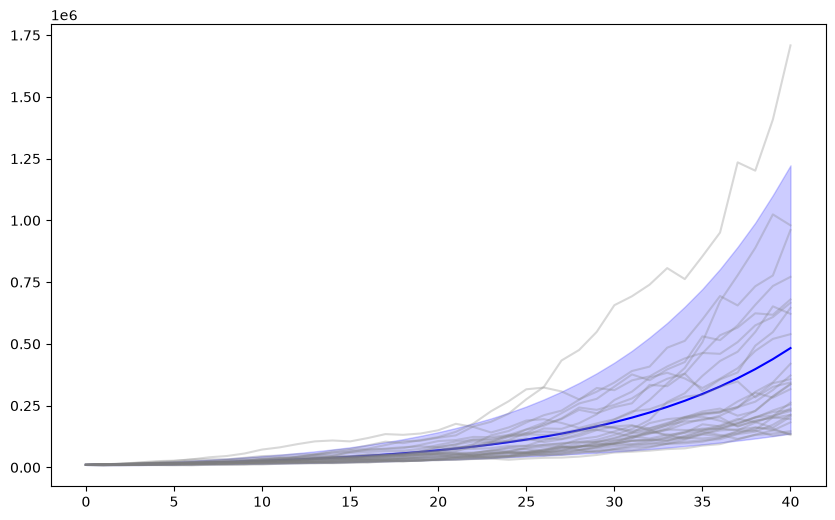

In [27]:
# plot some sample paths

portfolio_weights = np.array(PORTFOLIO_WEIGHTS)
asset_data = paths[:, :, :3]

wealth = np.zeros((n_paths, YEARS_PER_PATH + 1))
wealth[:, 0] = INITIAL_INVESTMENT

for t in range(YEARS_PER_PATH):
    returns_t = asset_data[:, t, :]
    portfolio_returns_t = np.dot(returns_t, portfolio_weights)
    wealth[:, t + 1] = wealth[:, t] * (1 + portfolio_returns_t)

# compute some statistics
mean_wealth = np.mean(wealth, axis=0)
percentiles_wealth = np.percentile(wealth, PERCENTILES, axis=0)

plt.figure(figsize=FIGSIZE_MAIN)
plt.plot(mean_wealth, label="Mean Wealth", color=COLOR_MAIN)
plt.fill_between(
    range(YEARS_PER_PATH + 1), 
    percentiles_wealth[0], 
    percentiles_wealth[-1], 
    color=COLOR_MAIN, 
    alpha=ALPHA_PERCENTILE_FILL, 
    label=f"{PERCENTILES[0]}th-{PERCENTILES[-1]}th Percentile"
)

# plot the first N_SAMPLE_PATHS_TO_PLOT paths
for i in range(min(N_SAMPLE_PATHS_TO_PLOT, n_paths)):
    plt.plot(wealth[i + SAMPLE_PATH_OFFSET], color=COLOR_SAMPLE_PATH, alpha=ALPHA_SAMPLE_PATH)

<module 'matplotlib.pyplot' from 'c:\\Users\\CallumDavidson\\Code\\MADS\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

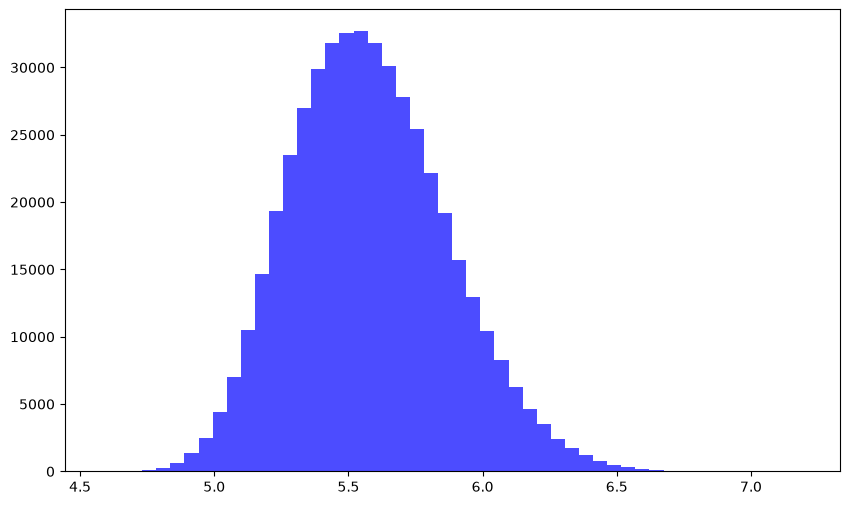

In [28]:
# plot histogram of final wealth
plt.figure(figsize=FIGSIZE_MAIN)
plt.hist(np.log10(wealth[:, -1]), bins=HISTOGRAM_BINS, color=COLOR_MAIN, alpha=ALPHA_HISTOGRAM)
plt

In [29]:
paths.shape

(463912, 40, 4)